In [ ]:
import sys
path = "../../.."
if path not in sys.path:
    sys.path.insert(0, path)


import matplotlib.pyplot as plt
import numpy as np
from data_retrieval import lipade_groundtruth
from data_retrieval.tools.data_loader import getDataLoader
from PIL import Image
from sklearn.metrics.pairwise import cosine_similarity
from data_retrieval import lipade_groundtruth
from clustering.clustering import getPredictionFromThreshold
import clustering.evaluators as evaluators
import csv
import os

from torchvision.models import resnet18, ResNet18_Weights
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR

import clip
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
from transformers import CLIPModel, CLIPProcessor
from tqdm import tqdm
import numpy as np
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

from torchvision.transforms import Compose, Resize, CenterCrop, ToTensor, Normalize
try:
    from torchvision.transforms import InterpolationMode
    BICUBIC = InterpolationMode.BICUBIC
except ImportError:
    BICUBIC = Image.BICUBIC


device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
device = "cpu"
print(device)

optimizerFunc = optim.Adam
temperature = 0.07
learningRate = 3e-4
batch_size = 128 # metttre plus grand
workers = 2
extract = 800
epochs = 20
corpus = "lipade_groundtruth"
resultsPath = "/home/renard/HighVision_moi/representation/multimodal/results/distance/" + corpus + "/"
weightPath = "/home/renard/HighVision_moi/representation/multimodal/results/weights/"
lossPath = "/home/renard/HighVision_moi/representation/multimodal/results/loss/"


csv_filename = "results_slip.csv"


torch.cuda.empty_cache()



cuda:0


In [73]:
# ## Dataset

# Test
xSim,_,ySim = lipade_groundtruth.getDataset(mode = 'similar') #, uniform=True)
_,_,y_test = lipade_groundtruth.getDataset(mode="similar")

imagesSim = []
for i in range(len(xSim)):
    try:
        imagesSim.append(Image.open(xSim[i]).convert('RGB'))
    except:
        print("Error loading image:", xSim[i])



def _convert_image_to_rgb(image):
    return image.convert("RGB")

trans_prepro = Compose([
        Resize(224, interpolation=BICUBIC),
        CenterCrop(224),
        _convert_image_to_rgb,
        ToTensor(),
        Normalize((0.48145466, 0.4578275, 0.40821073), (0.26862954, 0.26130258, 0.27577711)),
    ])

testLoader = getDataLoader(imagesSim, None, trans_prepro, False, batch_size, shuffle=False, num_workers=2)


# Train/val
# Images
x,m,_ = lipade_groundtruth.getDataset(mode="unique") #, uniform=True)

is_recto = np.array(m[2])
x = np.array(x)[is_recto]

# Captions
captions = m[1]
images_per_captions = {}
images = []
for file,prompt in captions.keys():
    images_per_captions[prompt] = []

for i in range(len(x)):
    f = '/'.join(x[i].split('/')[-2:])
    if (f, prompt) not in captions.keys():
        images.append(x[i])

x = x.tolist()
for im in images:
    x.remove(im)

for prompt in images_per_captions.keys():
    for i in range(len(x)):
        f = '/'.join(x[i].split('/')[-2:])
        images_per_captions[prompt].append(captions[(f, prompt)])

class CustomDataset(Dataset):
    def __init__(self, image_paths, captions):
        self.image_paths = image_paths
        self.captions = captions
        self.transform = trans_prepro
        #transforms.Compose([
        #    transforms.Resize((224, 224)),
        #    transforms.ToTensor()])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image, image_path, self.captions[idx], idx
    



captions = images_per_captions["a black and white photo of "]

train_images, val_images, train_captions, val_captions = train_test_split(
    x, captions, test_size=0.1, random_state=42
)

train_loader = DataLoader(CustomDataset(train_images, train_captions), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(CustomDataset(val_images, val_captions), batch_size=batch_size, shuffle=False)



In [ ]:
from degradations.methods import transforms_atkinson_dithering, transforms_bayer_halftoning, transforms_floyd_steinberg_halftoning, transforms_drawing, transforms_erased_element, transforms_paint, transforms_non_rectangular_frame, transforms_patchwork, transforms_photo_montage, transforms_picture_overlay, transforms_text_overlay, transforms_dirty_rollers, transforms_add_gaussian_noise, transforms_add_salt_and_pepper_noise, transforms_bleedthrough, transforms_contrast, transforms_crumpled_paper, transforms_folded_paper, transforms_ink_bleed, transforms_book, transforms_stains, transforms_scribbles, transforms_torn_paper


class transforms_SepiaFilter(nn.Module):
    def __init__(self):
        super(transforms_SepiaFilter, self).__init__()

    def __call__(self, batch):
        sepia_filter = torch.tensor([[0.393, 0.769, 0.189],
                                     [0.349, 0.686, 0.168],
                                     [0.272, 0.534, 0.131]], device=batch.device)
        batch = torch.einsum('ijkl,mj->imkl', batch, sepia_filter)
        return batch.clamp(0, 1)



list_degrads = [
        # halftone
        transforms_floyd_steinberg_halftoning(),
        transforms_atkinson_dithering(),
        transforms_bayer_halftoning(),
        # layout
        transforms_picture_overlay(),
        transforms_text_overlay(),
        transforms_non_rectangular_frame(),
        transforms_photo_montage(),
        # human
        transforms_erased_element(),
        #transforms_drawing(),
        #transforms_paint(),
        # noise
        transforms_add_gaussian_noise(),
        transforms_add_salt_and_pepper_noise(),
        transforms_dirty_rollers(),
        # stains
        #transforms_scribbles(),
        transforms_stains(),
        transforms_ink_bleed(),
        transforms_bleedthrough(),
        # texture
        transforms_crumpled_paper(),
        transforms_folded_paper(),
        transforms_torn_paper(),
        # sepia
        transforms_SepiaFilter()]



transform = transforms.Compose([
            transforms.RandomChoice([
                transforms.RandomResizedCrop(size=224, scale=(1/2, 1), ratio=(1, 1)),
                transforms.RandomHorizontalFlip(p=1),
                transforms.RandomVerticalFlip(p=1),
                *list_degrads]),
            transforms.ColorJitter(brightness=0.8, contrast=0.8, saturation=0.8, hue=0.2),
            transforms.RandomApply([transforms.GaussianBlur(kernel_size=9)], p=0.5),
        ])



# CLIP sans ré-entraînement

Thresholds: 100%|██████████| 100/100 [00:01<00:00, 84.13it/s]


(np.float64(0.15761568989260377),
 np.float64(0.34783065710389055),
 np.float64(0.17494929197456294),
 np.float64(0.3702359346642468))

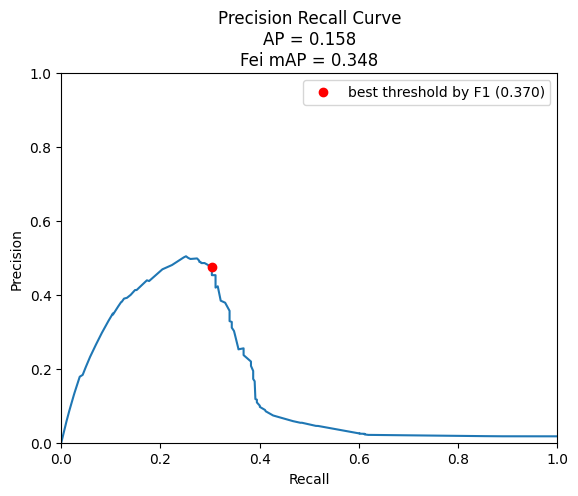

In [ ]:
"""
# Sans entrainement
trans_re = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])
testLoader = getDataLoader(imagesSim, None, trans_re, False, batch_size, shuffle=False, num_workers=2)


# Charger CLIP
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32") #.to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Projection SimCLR
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=512, out_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )
    def forward(self, x):
        return self.mlp(x)

proj = ProjectionMLP(in_dim=512) #.to(device)

test(clip_model, proj, "clip_baseline", testLoader, y_test, use_proj=False)
"""

Thresholds: 100%|██████████| 100/100 [00:01<00:00, 84.48it/s]


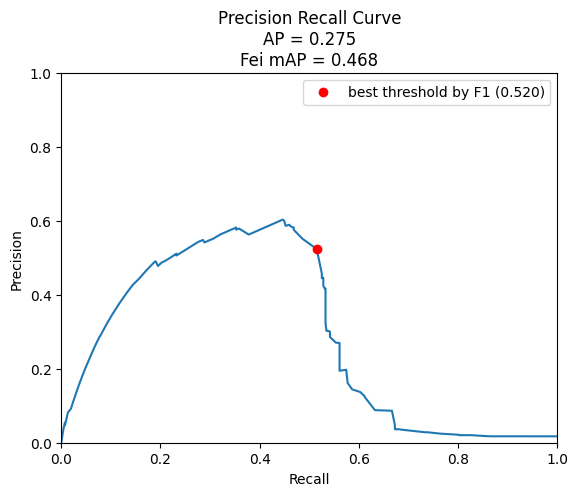

In [ ]:

model, _ = clip.load("ViT-B/32", device)

testLoader = getDataLoader(imagesSim, None, trans_prepro, False, batch_size, shuffle=False, num_workers=2)



representations = []
with torch.no_grad():
    for batch in testLoader:
        batch = model.encode_image(batch.to(device))
        for repr in batch.tolist():
            representations.append(repr)
            

representations = np.array(representations).reshape((len(xSim),-1))

sim = cosine_similarity(representations, representations)

distance = 1 - (sim+1)/2
distance -= np.diag(distance)


method = f"slip_testvitb32"

thresholds_precision = 1000
thresholds = np.linspace(0, 1, thresholds_precision)

precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y_test)
f1 = np.max(f1s)
AP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y_test, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y_test)
fei = evaluators.fei_mAP(y_test, distance)
sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)

# CLIP seul opti

In [50]:
class ClipDataset(Dataset):
    def __init__(self, image_paths, captions):
        self.image_paths = image_paths
        self.captions = captions
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image, self.captions[idx]
    

class ClipDataset_test(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image



captions = images_per_captions["a black and white photo of "]

train_images, val_images, train_captions, val_captions = train_test_split(
    x, captions, test_size=0.1, random_state=42
)

train_dataset = ClipDataset(train_images, train_captions)
val_dataset = ClipDataset(val_images, val_captions)
test_loader_clip = DataLoader(ClipDataset_test(xSim), batch_size=batch_size, shuffle=False)


In [51]:
class ClipDataset_test(Dataset):
    def __init__(self, image_paths):
        self.image_paths = image_paths
        self.transform = transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor()])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        image_path = self.image_paths[idx]
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)
        return image

test_loader_clip = DataLoader(ClipDataset_test(xSim), batch_size=batch_size, shuffle=False)


In [52]:
import torch
import torch.nn.functional as F
import clip
import os
import json


class CLIPWithProjector(torch.nn.Module):

    def __init__(self, clip_model, projector_dim=512, use_image_projector=True, use_text_projector=True):
        """
        Initialise l'enveloppe CLIP avec des projecteurs.

        Args:
            clip_model (torch.nn.Module): Modèle CLIP pré-entraîné.
            projector_dim (int): Dimension de sortie du projecteur.
            use_image_projector (bool): Si False, désactive le projecteur image.
            use_text_projector (bool): Si False, désactive le projecteur texte.
        """
        super(CLIPWithProjector, self).__init__()
        self.clip_model = clip_model.float()
        self.use_image_projector = use_image_projector
        self.use_text_projector = use_text_projector

        self.image_projector = torch.nn.Sequential(
            torch.nn.Linear(clip_model.visual.output_dim, projector_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(projector_dim, projector_dim),
        )

        self.text_projector = torch.nn.Sequential(
            torch.nn.Linear(clip_model.text_projection.shape[1], projector_dim),
            torch.nn.ReLU(),
            torch.nn.Dropout(0.2),
            torch.nn.Linear(projector_dim, projector_dim),
        )

    def tokenize(self, texts):
        """Tokenise une liste de textes à l’aide du tokenizer CLIP."""
        return clip.tokenize(texts)

    def encode_image(self, images):
        features = self.clip_model.encode_image(images)
        features = F.normalize(features.to(dtype=torch.float32), dim=-1, p=2)

        if self.use_image_projector:
            features = self.image_projector(features)
            features = F.normalize(features, dim=-1, p=2)

        return features

    def encode_text(self, tokenized_texts):
        features = self.clip_model.encode_text(tokenized_texts)
        features = F.normalize(features.to(dtype=torch.float32), dim=-1, p=2)

        if self.use_text_projector:
            features = self.text_projector(features)
            features = F.normalize(features, dim=-1, p=2)

        return features

    def forward(self, images, texts):
        image_features = self.encode_image(images)
        text_features = self.encode_text(texts)
        return image_features, text_features
    





def load_clip_model():
    """
    Charge le modèle CLIP ViT-B/32 et déverrouille tous les paramètres pour un fine-tuning complet.

    Returns:
        model (torch.nn.Module): CLIP prêt pour fine-tuning.
        preprocess (Callable): Fonction de prétraitement d'images.
        device (str): Appareil utilisé.
    """
    device = "cuda" if torch.cuda.is_available() else "cpu"
    device = "cpu"


    #ViT-L/14
    model, preprocess = clip.load("ViT-B/32", device=device)

    # Permet de mettre à jour tous les poids pendant le fine-tuning
    for param in model.parameters():
        param.requires_grad = True

    return model, preprocess, device






def clip_loss(image_embeddings, text_embeddings, temperature=0.07):
    """
    Calcule la perte contrastive CLIP (InfoNCE symétrique).

    Args:
        image_embeddings (Tensor): Embeddings des images.
        text_embeddings (Tensor): Embeddings des textes.
        temperature (float): Température pour la normalisation des logits.
    """
    image_embeddings = F.normalize(image_embeddings, dim=1)
    text_embeddings = F.normalize(text_embeddings, dim=1)

    logits_per_image = image_embeddings @ text_embeddings.T
    logits_per_text = text_embeddings @ image_embeddings.T

    logits_per_image /= temperature
    logits_per_text /= temperature

    labels = torch.arange(len(image_embeddings)).to(image_embeddings.device)

    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)

    return (loss_i + loss_t) / 2



def progressively_unfreeze(model_clip, current_epoch, schedule):
    """
    Débloque progressivement les couches du modèle CLIP selon le planning donné.

    Args:
        model_clip: Modèle CLIP de base.
        current_epoch (int): Époque actuelle.
        schedule (dict): Dictionnaire avec epoch -> nombre de couches à débloquer.
    """
    # Trouver le nombre de couches à débloquer selon l'époque
    epochs = sorted(schedule.keys())
    nb_layers_to_unfreeze = 0
    for e in epochs:
        if current_epoch >= e:
            nb_layers_to_unfreeze = schedule[e]
        else:
            break

    print(f"[Epoch {current_epoch}] Unfreezing {nb_layers_to_unfreeze} layer(s)")

    # Appliquer aux blocs visuels
    total_blocks = len(model_clip.visual.transformer.resblocks)
    for i in range(total_blocks - nb_layers_to_unfreeze, total_blocks):
        for param in model_clip.visual.transformer.resblocks[i].parameters():
            param.requires_grad = True

    # Appliquer aux blocs textuels
    total_blocks = len(model_clip.transformer.resblocks)
    for i in range(total_blocks - nb_layers_to_unfreeze, total_blocks):
        for param in model_clip.transformer.resblocks[i].parameters():
            param.requires_grad = True

            

def fine_tune_clip(model_folder, model: CLIPWithProjector, train_dataset, val_dataset,
                   device, epochs=20, batch_size=16, lr=1e-5, patience=5):
    """
    Fine-tune un modèle CLIP avec projecteur à l'aide d'une perte contrastive.

    Args:
        model_folder (str): Emplacement de sauvegarde du modèle.
        model (CLIPWithProjector): Modèle CLIP avec projecteur.
        train_dataset (Dataset): Dataset d'entraînement.
        val_dataset (Dataset): Dataset de validation.
        device (torch.device): Périphérique d'entraînement.
        epochs (int): Nombre d'époques.
        batch_size (int): Taille des batches.
        lr (float): Taux d'apprentissage.
        patience (int): Nombre d'époques sans amélioration avant early stopping.
    """
    train_loader = DataLoader(train_dataset, batch_size=batch_size, num_workers=4)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=4)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=2)

    best_val_loss = float("inf")
    epochs_no_improve = 0
    best_model_state = None

    train_losses = []
    val_losses = []

    unfreeze_schedule = {
        0: 1,   # à l'époque 5, on débloque 1 couche
        8: 2,   # à partir de l'époque 8, 2 couches débloquées
        11: 3    # à partir de l'époque 11, 3 couches débloquées
    }

    for epoch in range(epochs):
        progressively_unfreeze(model.clip_model, epoch, unfreeze_schedule)

        model.train()
        total_train_loss = 0.0

        # tqdm pour l'entraînement
        train_bar = tqdm(enumerate(train_loader), total=len(train_loader), desc=f"[Train] Epoch {epoch+1}/{epochs}")
        for batch_idx, (images, texts) in train_bar:
            images = images.to(device)
            tokenized = model.tokenize(texts).to(device)

            image_embeds, text_embeds = model(images, tokenized)
            loss = clip_loss(image_embeds, text_embeds)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()
            train_bar.set_postfix(loss=loss.item())

        avg_train_loss = total_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        print(f"[Train] Epoch {epoch+1}, Average Loss: {avg_train_loss:.4f}")

        # Phase de validation
        model.eval()
        total_val_loss = 0.0
        val_bar = tqdm(val_loader, total=len(val_loader), desc=f"[Val] Epoch {epoch+1}/{epochs}")

        with torch.no_grad():
            for images, texts in val_bar:
                images = images.to(device)
                tokenized = model.tokenize(texts).to(device)

                image_embeds, text_embeds = model(images, tokenized)
                loss = clip_loss(image_embeds, text_embeds)

                total_val_loss += loss.item()
                val_bar.set_postfix(loss=loss.item())

        avg_val_loss = total_val_loss / len(val_loader)
        scheduler.step(avg_val_loss)
        val_losses.append(avg_val_loss)
        print(f"[Val] Epoch {epoch+1}, Average Validation Loss: {avg_val_loss:.4f}")

        # Sauvegarde du meilleur modèle
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            epochs_no_improve = 0
            best_model_state = model.state_dict()
            print(f"--> Validation loss improved. Model saved.")
        else:
            epochs_no_improve += 1
            print(f"--> No improvement. Patience: {epochs_no_improve}/{patience}")
            if epochs_no_improve >= patience:
                print("Early stopping triggered.")
                break

        torch.save(model.state_dict(), f"c1ip_opti_{model_folder}.pth")
    # Chargement du meilleur modèle
    if best_model_state:
        model.load_state_dict(best_model_state)

    # Sauvegarde des courbes de loss
    with open(f"{model_folder}/losses.json", "w") as f:
        json.dump({"train_losses": train_losses, "val_losses": val_losses}, f)

    plt.plot(train_losses, label="Train Loss")
    plt.plot(val_losses, label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.title("Training and Validation Loss")
    plt.savefig(os.path.join(model_folder, "loss_curve.png"))
    plt.close()

    print("Fine-tuning terminé!")

In [7]:
model_clip, preprocess, device = load_clip_model()
model = CLIPWithProjector(model_clip,use_image_projector=True,use_text_projector=True)

fine_tune_clip("fine_tuned_clip_1", model, train_dataset, val_dataset, device, epochs=20, batch_size=16, lr=1e-5, patience=5)

[Epoch 0] Unfreezing 1 layer(s)


[Train] Epoch 1/20: 100%|██████████| 290/290 [10:21<00:00,  2.14s/it, loss=2.11]


[Train] Epoch 1, Average Loss: 2.5162


[Val] Epoch 1/20: 100%|██████████| 33/33 [00:13<00:00,  2.36it/s, loss=0.468]


[Val] Epoch 1, Average Validation Loss: 2.2121
--> Validation loss improved. Model saved.
[Epoch 1] Unfreezing 1 layer(s)


...

[Val] Epoch 11, Average Validation Loss: 1.6987
--> No improvement. Patience: 4/5
[Epoch 11] Unfreezing 3 layer(s)


[Train] Epoch 12/20: 100%|██████████| 290/290 [07:08<00:00,  1.48s/it, loss=0.0465]


[Train] Epoch 12, Average Loss: 0.1217


[Val] Epoch 12/20: 100%|██████████| 33/33 [00:19<00:00,  1.69it/s, loss=0.547]


[Val] Epoch 12, Average Validation Loss: 1.7119
--> No improvement. Patience: 5/5
Early stopping triggered.
Fine-tuning terminé!


In [53]:
model_clip, preprocess, device = load_clip_model()
model = CLIPWithProjector(model_clip,use_image_projector=True,use_text_projector=True)
model.load_state_dict(torch.load("c1ip_opti_fine_tuned_clip_1.pth", map_location=device))

<All keys matched successfully>

In [54]:
def test(clip_model, name, testLoader, y_test):
    # Test 
    representations = []
    with torch.no_grad():
        for batch in testLoader:
            batch = clip_model.encode_image(batch) #.to(device))
            for repr in batch.tolist():
                representations.append(repr)
    
    sim = cosine_similarity(representations, representations)

    distance = 1 - (sim+1)/2
    distance -= np.diag(distance)

    np.save(resultsPath + f"slip_{name}.npy", distance)

    method = f"slip_{name}"

    thresholds_precision = 1000
    thresholds = np.linspace(0, 1, thresholds_precision)

    precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y_test)
    f1 = np.max(f1s)
    AP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y_test, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")
    thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
    precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y_test)
    fei = evaluators.fei_mAP(y_test, distance)
    sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)


    # Création ou ouverture du fichier en mode append
    with open(csv_filename, mode="a", newline="") as file:
        writer = csv.writer(file)

        # Écrire l'en-tête si le fichier est vide
        if file.tell() == 0:
            writer.writerow(["trial_name", "ap", "fei", "sam", "f1"])

        # Écriture des résultats
        writer.writerow([name, AP, fei, sam, f1])

    bestPredictedY = getPredictionFromThreshold(thresholds[bestThresholdIndex], distance)
    np.save("/home/renard/HighVision_moi/clustering/clusters/" + corpus + "/" + method + ".npy", bestPredictedY)

Thresholds: 100%|██████████| 100/100 [00:02<00:00, 39.98it/s]


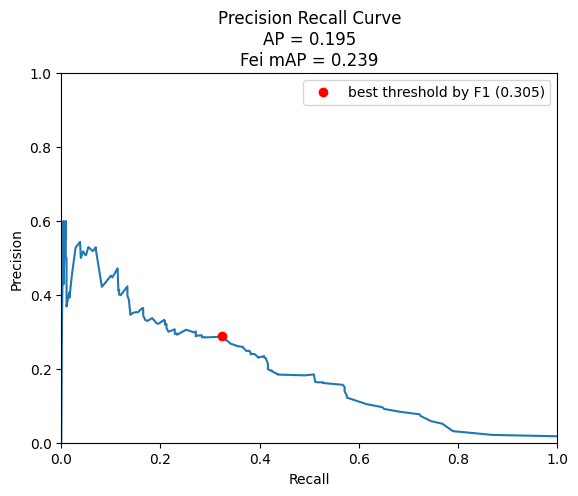

In [55]:
test(model, "clip_opti_test1", test_loader_clip, y_test)

# SLIP

## Modele

In [76]:
# Charger CLIP
"""
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32") #.to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")


# Projection SimCLR
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=512, out_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )
    def forward(self, x):
        return self.mlp(x)

proj = ProjectionMLP(in_dim=512) #.to(device)

# Optimizer
optimizer = optim.AdamW(
    list(clip_model.vision_model.parameters()) + list(proj.parameters()),
    lr=5e-6
)+ list(proj.parameters())
"""

model, _ = clip.load("ViT-B/32", device)
optimizer = optim.AdamW(
    list(model.parameters()),
    lr=5e-6
)

temperature = 0.07
lambda_clip = 1.0
lambda_simclr = 1.0

## Loss

In [ ]:
# SimCLR Loss
def infoNCEloss(z1, z2, t=1):
    z = torch.cat([z1, z2], dim=0)

    s = F.cosine_similarity(z.unsqueeze(1), z.unsqueeze(0), dim=-1)
    exp_s = torch.exp(s / t)
    indicatorMask = torch.eye(s.shape[0], dtype=torch.bool, device=z.device) # True on diagonal, False elsewhere
    exp_s = exp_s.masked_fill(indicatorMask, 0)

    numerator = F.cosine_similarity(z1, z2, dim=-1)      # for z1
    numerator = torch.cat([numerator, numerator], dim=0) # for z2
    numerator = torch.exp(numerator / t)

    denominator = exp_s.sum(dim=1)

    l = -torch.log(numerator / denominator)
    return l.mean()


# CLIP Loss
def clip_similarity_loss(image_embeds, text_embeds, t):
    image_embeddings = F.normalize(image_embeds, dim=1)
    text_embeddings = F.normalize(text_embeds, dim=1)

    logits_per_image = image_embeddings @ text_embeddings.T
    logits_per_text = text_embeddings @ image_embeddings.T

    logits_per_image /= t
    logits_per_text /= t

    labels = torch.arange(len(image_embeddings)).to(image_embeddings.device)

    loss_i = F.cross_entropy(logits_per_image, labels)
    loss_t = F.cross_entropy(logits_per_text, labels)

    return (loss_i + loss_t) / 2


def compute_validation_losses(val_loader, clip_model, proj, transform):
    clip_model.eval()
    proj.eval()

    sim_losses = []
    clip_losses = []

    with torch.no_grad():
        for (img, img_paths, captions, idx) in val_loader:

            images = [Image.open(p).convert("RGB") for p in img_paths]

            # --- SIMCLR ---
            x = img
            x2 = transform(img)

            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            sim_loss = infoNCEloss(z1, z2, temperature)
            sim_losses.append(sim_loss.item())

            # --- CLIP ---
            inputs = processor(images=images, text=captions,
                               return_tensors="pt", padding=True)
            outputs = clip_model(**inputs)

            img_emb = outputs.image_embeds
            txt_emb = outputs.text_embeds

            clip_loss = clip_similarity_loss(img_emb, txt_emb, temperature)
            clip_losses.append(clip_loss.item())

    clip_model.train()
    proj.train()

    return np.mean(sim_losses), np.mean(clip_losses), np.mean(sim_losses) + np.mean(clip_losses)




def compute_validation_losses_new(val_loader, clip_model, transform):
    clip_model.eval()

    sim_losses = []
    clip_losses = []

    with torch.no_grad():
        for (img, img_paths, captions, idx) in val_loader:

            images = [Image.open(p).convert("RGB") for p in img_paths]

            # --- SIMCLR ---
            x = img
            x2 = transform(img)

            v1 = clip_model.encode_image(x)
            v2 = clip_model.encode_image(x2)


            sim_loss = infoNCEloss(v1, v2, temperature)
            sim_losses.append(sim_loss.item())

            # --- CLIP ---
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = clip_model(img, text)

            clip_loss = clip_similarity_loss(img_emb, txt_emb, temperature)
            clip_losses.append(clip_loss.item())

    clip_model.train()

    return np.mean(sim_losses), np.mean(clip_losses), np.mean(sim_losses) + np.mean(clip_losses)





## Training functions

### Joint

In [ ]:
# Training Loop
def train_joint(train_loader, val_loader, transform, name, epochs=10, lambda_clip = 1.0, lambda_simclr = 1.0):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_joint_{name}"):
        os.mkdir(weightPath+f"SLIP_joint_{name}")

    for epoch in range(epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR PART ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP PART ---
            
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            img_emb = outputs.image_embeds
            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            # --- TOTAL LOSS ---
            loss_total = lambda_simclr * loss_simclr + lambda_clip * loss_clip
            
            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())
        
        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_joint_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR and CLIP")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_joint_{name}.png")
    plt.close()


In [ ]:

def train_joint_new(train_loader, transform, name, epochs=10):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []


    if not os.path.exists(weightPath+f"SLIP_joint_{name}"):
        os.mkdir(weightPath+f"SLIP_joint_{name}")

    for epoch in range(epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):

            # --- SIMCLR PART ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)

            # --- CLIP PART ---
            
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            # --- TOTAL LOSS ---
            loss_total = lambda_simclr * loss_simclr + lambda_clip * loss_clip
            
            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())
        
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_joint_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR and CLIP")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_joint_{name}.png")
    plt.close()


### simclr_then_clip

In [ ]:
def train_simclr_then_clip(train_loader, val_loader, transform, name, epochs=10, freeze_simclr=False):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_simclr_then_clip_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_then_clip_{name}")


    # --- SIMCLR PART FIRST ---

    for epoch in range(int(epochs/2)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs)
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        
        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_{name}/{epoch}.pth")
    


    # --- CLIP PART SECOND ---

    if freeze_simclr:
        # Freeze all vision model parameters
        for param in clip_model.vision_model.parameters():
            param.requires_grad = False


    for epoch in range(int(epochs/2), epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            with torch.no_grad():
                # --- SIMCLR  ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP ---
            
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            
            if freeze_simclr:
                img_emb = outputs.image_embeds.detach()
            else:
                img_emb = outputs.image_embeds

            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/2), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR then CLIP")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_then_clip_{name}.png")
    plt.close()


In [ ]:
def train_simclr_then_clip_new(train_loader, val_loader, transform, name, epochs=10, freeze_simclr=False):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_simclr_then_clip_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_then_clip_{name}")


    # --- SIMCLR PART FIRST ---

    for epoch in range(int(epochs/2)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)
        
        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_{name}/{epoch}.pth")
    

    # --- CLIP PART SECOND ---

    if freeze_simclr:
        # Freeze all vision model parameters
        for param in model.visual.parameters():
            param.requires_grad = False


    for epoch in range(int(epochs/2), epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            with torch.no_grad():
                # --- SIMCLR  ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)
                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)


            # --- CLIP ---
            
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)
            
            if freeze_simclr:
                img_emb = img_emb.detach()


            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/2), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR then CLIP")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_then_clip_{name}.png")
    plt.close()

### clip_then_simclr

In [ ]:
def train_clip_then_simclr(train_loader, val_loader, transform, name, epochs=30):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_clip_then_simclr_{name}"):
        os.mkdir(weightPath+f"SLIP_clip_then_simclr_{name}")



    # --- CLIP PART FIRST ---

    for epoch in range(int(epochs/2)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]

            with torch.no_grad():
                # --- SIMCLR ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)
                
                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP ---
                
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            img_emb = outputs.image_embeds
            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_clip_then_simclr_{name}/{epoch}.pth")
    


    # --- SIMCLR PART SECOND ---

    for epoch in range(int(epochs/2), epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            
            # --- SIMCLR  ---
                
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)


            with torch.no_grad():
                # --- CLIP ---
                
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs)
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)
        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_clip_then_simclr_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/2), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: CLIP then SimCLR")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_clip_then_simclr_{name}.png")
    plt.close()


In [ ]:
def train_clip_then_simclr_new(train_loader, val_loader, transform, name, epochs=30):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_clip_then_simclr_{name}"):
        os.mkdir(weightPath+f"SLIP_clip_then_simclr_{name}")



    # --- CLIP PART FIRST ---

    for epoch in range(int(epochs/2)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):

            with torch.no_grad():
                # --- SIMCLR ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)
                
                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)

            # --- CLIP ---
                
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_clip_then_simclr_{name}/{epoch}.pth")
    


    # --- SIMCLR PART SECOND ---

    for epoch in range(int(epochs/2), epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            
            # --- SIMCLR  ---
                
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)


            with torch.no_grad():
                # --- CLIP ---
                
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)
        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_clip_then_simclr_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/2), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: CLIP then SimCLR")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_clip_then_simclr_{name}.png")
    plt.close()

### simclr_then_clip_then_both

In [ ]:
def train_simclr_then_clip_then_both(train_loader, val_loader, transform, name, epochs=30):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    if not os.path.exists(weightPath+f"SLIP_simclr_then_clip_then_both_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_then_clip_then_both_{name}")


    # --- SIMCLR PART FIRST ---

    for epoch in range(int(epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs)
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        
        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    


    # --- CLIP PART SECOND ---

    for epoch in range(int(epochs/3), int(2*epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            with torch.no_grad():
                # --- SIMCLR  ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP ---
            
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            
           
            img_emb = outputs.image_embeds

            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")

    

    # JOINT PART
    for epoch in range(int(2*epochs/3),epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR PART ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP PART ---
            
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            img_emb = outputs.image_embeds
            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            # --- TOTAL LOSS ---
            loss_total = lambda_simclr * loss_simclr + lambda_clip * loss_clip
            
            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/3), color='r', linestyle='--')
    plt.axvline(x=int(2*epochs/3), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR then CLIP then both")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_then_clip_then_both_{name}.png")
    plt.close()


In [ ]:
def train_simclr_then_clip_then_both_new(train_loader, val_loader, transform, name, epochs=30):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    if not os.path.exists(weightPath+f"SLIP_simclr_then_clip_then_both_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_then_clip_then_both_{name}")


    # --- SIMCLR PART FIRST ---

    for epoch in range(int(epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        
        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    


    # --- CLIP PART SECOND ---

    for epoch in range(int(epochs/3), int(2*epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            with torch.no_grad():
                # --- SIMCLR  ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)

            # --- CLIP ---
            
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")

    

    # JOINT PART
    for epoch in range(int(2*epochs/3),epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            # --- SIMCLR PART ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)

            # --- CLIP PART ---
            
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            # --- TOTAL LOSS ---
            loss_total = lambda_simclr * loss_simclr + lambda_clip * loss_clip
            
            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/3), color='r', linestyle='--')
    plt.axvline(x=int(2*epochs/3), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR then CLIP then both")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_then_clip_then_both_{name}.png")
    plt.close()

### clip_with_degrad

In [ ]:
def train_clip_with_degrad(train_loader, val_loader, transform, name, epochs=20, nb_dupli_degrad=3):
    clip_model.train()
    proj.train()
    losses_clip_all_epoch = []
    losses_clip_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_clip_with_degrad_{name}"):
        os.mkdir(weightPath+f"SLIP_clip_with_degrad_{name}")



    # --- CLIP PART FIRST ---

    for epoch in range(epochs):
        losses_clip = []
        val_losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            #images = [Image.open(p).convert("RGB") for p in img_paths]

            x = img #.to(device)
            inputs = processor(images=x, text=captions, return_tensors="pt", padding=True, do_rescale=False) #.to(device)

            outputs = clip_model(**inputs)
            img_emb = outputs.image_embeds
            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_clip.append(loss_clip.item())

            for _ in range(nb_dupli_degrad):
                x2 = transform(img).clamp(0, 1) #.to(device)
                
                inputs = processor(images=x2, text=captions, return_tensors="pt", padding=True, do_rescale=False) #.to(device)

                outputs = clip_model(**inputs)
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_clip.append(loss_clip.item())

 
        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] CLIP: {np.mean(losses_clip):.4f}")
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_clip_val_all_epoch.append(clip_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_clip_with_degrad_{name}/{epoch}.pth")
    

    plt.plot(losses_clip_all_epoch, label="CLIP Loss (train)", color='g')
    plt.plot(losses_clip_val_all_epoch, label="CLIP Loss (val)", color='r')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("CLIP with degradations")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_clip_with_degrad_{name}.png")
    plt.close()


In [ ]:
def train_clip_with_degrad_new(train_loader, val_loader, transform, name, epochs=20, nb_dupli_degrad=3):
    model.train()
    losses_clip_all_epoch = []
    losses_clip_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_clip_with_degrad_{name}"):
        os.mkdir(weightPath+f"SLIP_clip_with_degrad_{name}")



    for epoch in range(epochs):
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):

            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_clip.append(loss_clip.item())

            for _ in range(nb_dupli_degrad):
                x2 = transform(img).clamp(0, 1) #.to(device)
                
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(x2, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_clip.append(loss_clip.item())

 
        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] CLIP: {np.mean(losses_clip):.4f}")
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_clip_val_all_epoch.append(clip_val)

        torch.save({
            "clip": model.state_dict()
        }, weightPath+f"SLIP_clip_with_degrad_{name}/{epoch}.pth")
    

    plt.plot(losses_clip_all_epoch, label="CLIP Loss (train)", color='g')
    plt.plot(losses_clip_val_all_epoch, label="CLIP Loss (val)", color='r')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("CLIP with degradations")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_clip_with_degrad_{name}.png")
    plt.close()

### simclr_only

In [ ]:
def train_simclr_only(train_loader, val_loader, transform, name, epochs=10):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_simclr_only_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_only_{name}")


    # --- SIMCLR PART  ---

    for epoch in range(epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs)
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        
        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_only_{name}/{epoch}.pth")
    


    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR only")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_only_{name}.png")
    plt.close()


In [ ]:
def train_simclr_only_new(train_loader, val_loader, transform, name, epochs=10):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_simclr_only_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_only_{name}")


    # --- SIMCLR PART  ---

    for epoch in range(epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        
        torch.save({
            "clip": model.state_dict()
        }, weightPath+f"SLIP_simclr_only_{name}/{epoch}.pth")
    


    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR only")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_only_{name}.png")
    plt.close()

### alternate

In [ ]:
def train_alternate_clip_simclr(train_loader, val_loader, transform, name, epochs=10, step_alternate=5):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_alternate_clip_simclr_{name}"):
        os.mkdir(weightPath+f"SLIP_alternate_clip_simclr_{name}")


    for epoch in range(int(epochs/(2*step_alternate))):
        

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                images = [Image.open(p).convert("RGB") for p in img_paths]


                with torch.no_grad():
                
                    # --- SIMCLR ---
                    
                    x = img #.to(device)
                    x2 = transform(img) #.to(device)
                    
                    v1 = clip_model.get_image_features(pixel_values=x)
                    v2 = clip_model.get_image_features(pixel_values=x2)

                    z1 = proj(v1)
                    z2 = proj(v2)

                    loss_simclr = infoNCEloss(z1, z2, temperature)

                # --- CLIP ---
                    
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs) 
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())
            
            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

            print(f"[Epoch {i+step_alternate*2*epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": clip_model.state_dict(),
                "proj": proj.state_dict()
            }, weightPath+f"SLIP_alternate_clip_simclr_{name}/{i+step_alternate*2*epoch}.pth")
    


        # --- SIMCLR PART ---

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []
    

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                images = [Image.open(p).convert("RGB") for p in img_paths]
                
                
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)


                with torch.no_grad():
                    # --- CLIP ---
                    
                    inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                    outputs = clip_model(**inputs)
                    img_emb = outputs.image_embeds
                    txt_emb = outputs.text_embeds

                    loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
                
                optimizer.zero_grad()
                loss_simclr.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())

            # --- Validation ---
            sim_val, clip_val = compute_validation_losses(val_loader, clip_model, proj, transform)

            print(f"[Epoch {i+step_alternate*2*epoch+step_alternate}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)

            torch.save({
                "clip": clip_model.state_dict(),
                "proj": proj.state_dict()
            }, weightPath+f"SLIP_alternate_clip_simclr_{name}/{i+step_alternate*2*epoch+step_alternate}.pth")
        

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: alternate CLIP and SimCLR")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_alternate_clip_simclr_{name}.png")
    plt.close()



In [ ]:
def train_alternate_clip_simclr_new(train_loader, val_loader, transform, name, epochs=10, step_alternate=5):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []

    if not os.path.exists(weightPath+f"SLIP_alternate_clip_simclr_{name}"):
        os.mkdir(weightPath+f"SLIP_alternate_clip_simclr_{name}")


    for epoch in range(int(epochs/(2*step_alternate))):
        

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                
                with torch.no_grad():
                
                    # --- SIMCLR ---
                    
                    x = img #.to(device)
                    x2 = transform(img) #.to(device)
                    
                    v1 = model.encode_image(x)
                    v2 = model.encode_image(x2)

                    loss_simclr = infoNCEloss(v1, v2, temperature)

                # --- CLIP ---
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())
            
            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

            print(f"[Epoch {i+step_alternate*2*epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": model.state_dict(),
            }, weightPath+f"SLIP_alternate_clip_simclr_{name}/{i+step_alternate*2*epoch}.pth")
    


        # --- SIMCLR PART ---

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []
    

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                images = [Image.open(p).convert("RGB") for p in img_paths]
                
                
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)
                    
                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)



                with torch.no_grad():
                    # --- CLIP ---
                    text = clip.tokenize(list(captions))#.to(device)
                    img_emb, txt_emb = model(img, text)

                    loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
                
                optimizer.zero_grad()
                loss_simclr.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())

            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

            print(f"[Epoch {i+step_alternate*2*epoch+step_alternate}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": model.state_dict(),
            }, weightPath+f"SLIP_alternate_clip_simclr_{name}/{i+step_alternate*2*epoch+step_alternate}.pth")
        

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: alternate CLIP and SimCLR")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_alternate_clip_simclr_{name}.png")
    plt.close()

### simclr_then_clip_then_both

In [11]:
def train_simclr_then_clip_then_both(train_loader, val_loader, transform, name, epochs=30):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    if not os.path.exists(weightPath+f"SLIP_simclr_then_clip_then_both_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_then_clip_then_both_{name}")


    # --- SIMCLR PART FIRST ---

    for epoch in range(int(epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs)
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        
        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    


    # --- CLIP PART SECOND ---

    for epoch in range(int(epochs/3), int(2*epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            with torch.no_grad():
                # --- SIMCLR  ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP ---
            
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            
           
            img_emb = outputs.image_embeds

            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")

    

    # JOINT PART
    for epoch in range(int(2*epochs/3),epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR PART ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP PART ---
            
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            img_emb = outputs.image_embeds
            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            # --- TOTAL LOSS ---
            loss_total = lambda_simclr * loss_simclr + lambda_clip * loss_clip
            
            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/3), color='r', linestyle='--')
    plt.axvline(x=int(2*epochs/3), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR then CLIP then both")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_then_clip_then_both_{name}.png")
    plt.close()

In [ ]:
def train_simclr_then_clip_then_both_new(train_loader, val_loader, transform, name, epochs=30):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    if not os.path.exists(weightPath+f"SLIP_simclr_then_clip_then_both_{name}"):
        os.mkdir(weightPath+f"SLIP_simclr_then_clip_then_both_{name}")


    # --- SIMCLR PART FIRST ---

    for epoch in range(int(epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            # --- SIMCLR ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)
            
            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)

            with torch.no_grad(): # juste pour voir comment ca evolue du cote texte du coup
                # --- CLIP ---
                
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        
        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    


    # --- CLIP PART SECOND ---

    for epoch in range(int(epochs/3), int(2*epochs/3)):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            with torch.no_grad():
                # --- SIMCLR  ---
                
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)

            # --- CLIP ---
            
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")

    

    # JOINT PART
    for epoch in range(int(2*epochs/3),epochs):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            # --- SIMCLR PART ---
            
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)

            # --- CLIP PART ---
            
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

            # --- TOTAL LOSS ---
            loss_total = lambda_simclr * loss_simclr + lambda_clip * loss_clip
            
            optimizer.zero_grad()
            loss_total.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_simclr_then_clip_then_both_{name}/{epoch}.pth")
    

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=int(epochs/3), color='r', linestyle='--')
    plt.axvline(x=int(2*epochs/3), color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: SimCLR then CLIP then both")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_simclr_then_clip_then_both_{name}.png")
    plt.close()


### alternate_then_clip

In [ ]:
def train_alternate_then_clip(train_loader, val_loader, transform, name, epochs_total=60, step_alternate=5, epochs_clip_only=15):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    epochs = epochs_total - epochs_clip_only
    if not os.path.exists(weightPath+f"SLIP_alternate_then_clip_{name}"):
        os.mkdir(weightPath+f"SLIP_alternate_then_clip_{name}")


    for epoch in range(int(epochs/(2*step_alternate))):
        

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                images = [Image.open(p).convert("RGB") for p in img_paths]


                with torch.no_grad():
                
                    # --- SIMCLR ---
                    
                    x = img #.to(device)
                    x2 = transform(img) #.to(device)
                    
                    v1 = clip_model.get_image_features(pixel_values=x)
                    v2 = clip_model.get_image_features(pixel_values=x2)

                    z1 = proj(v1)
                    z2 = proj(v2)

                    loss_simclr = infoNCEloss(z1, z2, temperature)

                # --- CLIP ---
                    
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs) 
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())
            
            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

            print(f"[Epoch {i+step_alternate*2*epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": clip_model.state_dict(),
                "proj": proj.state_dict()
            }, weightPath+f"SLIP_alternate_then_clip_{name}/{i+step_alternate*2*epoch}.pth")
    


        # --- SIMCLR PART ---

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []
    

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                images = [Image.open(p).convert("RGB") for p in img_paths]
                
                
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)


                with torch.no_grad():
                    # --- CLIP ---
                    
                    inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                    outputs = clip_model(**inputs)
                    img_emb = outputs.image_embeds
                    txt_emb = outputs.text_embeds

                    loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
                
                optimizer.zero_grad()
                loss_simclr.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())

            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

            print(f"[Epoch {i+step_alternate*2*epoch+step_alternate}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": clip_model.state_dict(),
                "proj": proj.state_dict()
            }, weightPath+f"SLIP_alternate_then_clip_{name}/{i+step_alternate*2*epoch+step_alternate}.pth")
        

    for epoch in range(epochs, epochs_total):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            
            with torch.no_grad():
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)

            # --- CLIP ---
            
            inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

            outputs = clip_model(**inputs)
            
           
            img_emb = outputs.image_embeds

            txt_emb = outputs.text_embeds

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)
        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_alternate_then_clip_{name}/{epoch}.pth")

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=epochs, color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: alternate then only CLIP")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_alternate_then_clip_{name}.png")
    plt.close()

In [ ]:
def train_alternate_then_clip_new(train_loader, val_loader, transform, name, epochs_total=60, step_alternate=5, epochs_clip_only=15):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    epochs = epochs_total - epochs_clip_only
    if not os.path.exists(weightPath+f"SLIP_alternate_then_clip_{name}"):
        os.mkdir(weightPath+f"SLIP_alternate_then_clip_{name}")


    for epoch in range(int(epochs/(2*step_alternate))):
        

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []

            for (img, img_paths, captions, idx) in tqdm(train_loader):

                with torch.no_grad():
                
                    # --- SIMCLR ---
                    
                    x = img #.to(device)
                    x2 = transform(img) #.to(device)
                    
                    v1 = model.encode_image(x)
                    v2 = model.encode_image(x2)

                    loss_simclr = infoNCEloss(v1, v2, temperature)


                # --- CLIP ---
                    
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())
            
            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

            print(f"[Epoch {i+step_alternate*2*epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": model.state_dict(),
            }, weightPath+f"SLIP_alternate_then_clip_{name}/{i+step_alternate*2*epoch}.pth")
    


        # --- SIMCLR PART ---

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []
    

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)


                with torch.no_grad():
                    # --- CLIP ---
                    
                    text = clip.tokenize(list(captions))#.to(device)
                    img_emb, txt_emb = model(img, text)

                    loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
                
                optimizer.zero_grad()
                loss_simclr.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())

            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

            print(f"[Epoch {i+step_alternate*2*epoch+step_alternate}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": model.state_dict(),
            }, weightPath+f"SLIP_alternate_then_clip_{name}/{i+step_alternate*2*epoch+step_alternate}.pth")
        

    for epoch in range(epochs, epochs_total):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            with torch.no_grad():
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)

            # --- CLIP ---
            
            text = clip.tokenize(list(captions))#.to(device)
            img_emb, txt_emb = model(img, text)

            loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_clip.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)
        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_alternate_then_clip_{name}/{epoch}.pth")

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=epochs, color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: alternate then only CLIP")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_alternate_then_clip_{name}.png")
    plt.close()

### alternate_then_simclr

In [ ]:
def train_alternate_then_simclr(train_loader, val_loader, transform, name, epochs_total=60, step_alternate=5, epochs_clip_only=15):
    clip_model.train()
    proj.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    epochs = epochs_total - epochs_clip_only
    if not os.path.exists(weightPath+f"SLIP_alternate_then_simclr_{name}"):
        os.mkdir(weightPath+f"SLIP_alternate_then_simclr_{name}")


    for epoch in range(int(epochs/(2*step_alternate))):
        

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                images = [Image.open(p).convert("RGB") for p in img_paths]


                with torch.no_grad():
                
                    # --- SIMCLR ---
                    
                    x = img #.to(device)
                    x2 = transform(img) #.to(device)
                    
                    v1 = clip_model.get_image_features(pixel_values=x)
                    v2 = clip_model.get_image_features(pixel_values=x2)

                    z1 = proj(v1)
                    z2 = proj(v2)

                    loss_simclr = infoNCEloss(z1, z2, temperature)

                # --- CLIP ---
                    
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs) 
                img_emb = outputs.image_embeds
                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())
            
            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

            print(f"[Epoch {i+step_alternate*2*epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": clip_model.state_dict(),
                "proj": proj.state_dict()
            }, weightPath+f"SLIP_alternate_then_simclr_{name}/{i+step_alternate*2*epoch}.pth")
    


        # --- SIMCLR PART ---

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []
    

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                images = [Image.open(p).convert("RGB") for p in img_paths]
                
                
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = clip_model.get_image_features(pixel_values=x)
                v2 = clip_model.get_image_features(pixel_values=x2)

                z1 = proj(v1)
                z2 = proj(v2)

                loss_simclr = infoNCEloss(z1, z2, temperature)


                with torch.no_grad():
                    # --- CLIP ---
                    
                    inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                    outputs = clip_model(**inputs)
                    img_emb = outputs.image_embeds
                    txt_emb = outputs.text_embeds

                    loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
                
                optimizer.zero_grad()
                loss_simclr.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())

            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)

            print(f"[Epoch {i+step_alternate*2*epoch+step_alternate}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": clip_model.state_dict(),
                "proj": proj.state_dict()
            }, weightPath+f"SLIP_alternate_then_simclr_{name}/{i+step_alternate*2*epoch+step_alternate}.pth")
        

    for epoch in range(epochs, epochs_total):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            images = [Image.open(p).convert("RGB") for p in img_paths]
            
            # --- SIMCLR  ---
                    
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = clip_model.get_image_features(pixel_values=x)
            v2 = clip_model.get_image_features(pixel_values=x2)

            z1 = proj(v1)
            z2 = proj(v2)

            loss_simclr = infoNCEloss(z1, z2, temperature)
            
            with torch.no_grad():
                # --- CLIP ---
                
                inputs = processor(images=images, text=captions, return_tensors="pt", padding=True) #.to(device)

                outputs = clip_model(**inputs)
                
            
                img_emb = outputs.image_embeds

                txt_emb = outputs.text_embeds

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses(val_loader, clip_model, proj, transform)
        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": clip_model.state_dict(),
            "proj": proj.state_dict()
        }, weightPath+f"SLIP_alternate_then_simclr_{name}/{epoch}.pth")

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=epochs, color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: alternate then only InfoNCE")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_alternate_then_simclr_{name}.png")
    plt.close()

In [ ]:
def train_alternate_then_simclr_new(train_loader, val_loader, transform, name, epochs_total=60, step_alternate=5, epochs_clip_only=15):
    model.train()
    losses_simclr_all_epoch = []
    losses_clip_all_epoch = []
    losses_simclr_val_all_epoch = []
    losses_clip_val_all_epoch = []
    losses_sum_val_all_epoch = []
    
    epochs = epochs_total - epochs_clip_only
    if not os.path.exists(weightPath+f"SLIP_alternate_then_simclr_{name}"):
        os.mkdir(weightPath+f"SLIP_alternate_then_simclr_{name}")


    for epoch in range(int(epochs/(2*step_alternate))):
        
        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []

            for (img, img_paths, captions, idx) in tqdm(train_loader):

                with torch.no_grad():
                
                    # --- SIMCLR ---
                    
                    x = img #.to(device)
                    x2 = transform(img) #.to(device)
                
                    v1 = model.encode_image(x)
                    v2 = model.encode_image(x2)
                    loss_simclr = infoNCEloss(v1, v2, temperature)

                # --- CLIP ---
                    
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)

                
                optimizer.zero_grad()
                loss_clip.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())
            
            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

            print(f"[Epoch {i+step_alternate*2*epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": model.state_dict(),
            }, weightPath+f"SLIP_alternate_then_simclr_{name}/{i+step_alternate*2*epoch}.pth")
    


        # --- SIMCLR PART ---

        for i in range(step_alternate):
            losses_simclr = []
            losses_clip = []
    

            for (img, img_paths, captions, idx) in tqdm(train_loader):
                
                # --- SIMCLR  ---
                    
                x = img #.to(device)
                x2 = transform(img) #.to(device)

                v1 = model.encode_image(x)
                v2 = model.encode_image(x2)

                loss_simclr = infoNCEloss(v1, v2, temperature)


                with torch.no_grad():
                    # --- CLIP ---
                    text = clip.tokenize(list(captions))#.to(device)
                    img_emb, txt_emb = model(img, text)

                    loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
                
                optimizer.zero_grad()
                loss_simclr.backward()
                optimizer.step()

                losses_simclr.append(loss_simclr.item())
                losses_clip.append(loss_clip.item())

            # --- Validation ---
            sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)

            print(f"[Epoch {i+step_alternate*2*epoch+step_alternate}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
            losses_simclr_all_epoch.append(np.mean(losses_simclr))
            losses_clip_all_epoch.append(np.mean(losses_clip))
            losses_simclr_val_all_epoch.append(sim_val)
            losses_clip_val_all_epoch.append(clip_val)
            losses_sum_val_all_epoch.append(sum_val)

            torch.save({
                "clip": model.state_dict(),
            }, weightPath+f"SLIP_alternate_then_simclr_{name}/{i+step_alternate*2*epoch+step_alternate}.pth")
        

    for epoch in range(epochs, epochs_total):
        losses_simclr = []
        losses_clip = []

        for (img, img_paths, captions, idx) in tqdm(train_loader):
            
            # --- SIMCLR  ---
                    
            x = img #.to(device)
            x2 = transform(img) #.to(device)

            v1 = model.encode_image(x)
            v2 = model.encode_image(x2)

            loss_simclr = infoNCEloss(v1, v2, temperature)
            
            with torch.no_grad():
                # --- CLIP ---
                
                text = clip.tokenize(list(captions))#.to(device)
                img_emb, txt_emb = model(img, text)

                loss_clip = clip_similarity_loss(img_emb, txt_emb, temperature)
            
            optimizer.zero_grad()
            loss_simclr.backward()
            optimizer.step()

            losses_simclr.append(loss_simclr.item())
            losses_clip.append(loss_clip.item())

        # --- Validation ---
        sim_val, clip_val, sum_val = compute_validation_losses_new(val_loader, model, transform)
        print(f"[Epoch {epoch}] SimCLR: {np.mean(losses_simclr):.4f} | CLIP: {np.mean(losses_clip):.4f}")
        losses_simclr_all_epoch.append(np.mean(losses_simclr))
        losses_clip_all_epoch.append(np.mean(losses_clip))
        losses_simclr_val_all_epoch.append(sim_val)
        losses_clip_val_all_epoch.append(clip_val)
        losses_sum_val_all_epoch.append(sum_val)

        torch.save({
            "clip": model.state_dict(),
        }, weightPath+f"SLIP_alternate_then_simclr_{name}/{epoch}.pth")

    plt.plot(losses_simclr_all_epoch, label="InfoNCE Loss", color='b')
    plt.plot(losses_clip_all_epoch, label="CLIP Loss", color='g')
    plt.plot(losses_simclr_val_all_epoch, label="Val InfoNCE", color='r')
    plt.plot(losses_clip_val_all_epoch,   label="Val CLIP", color='orange')
    plt.plot(losses_sum_val_all_epoch,   label="Val CLIP+InfoNCE", color='yellow')
    plt.axvline(x=epochs, color='r', linestyle='--')
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.title("SLIP Training: alternate then only InfoNCE")
    plt.legend()
    plt.savefig(lossPath+f"loss_slip_alternate_then_simclr_{name}.png")
    plt.close()

## Training launch

#### Old

In [ ]:
train_clip_with_degrad(train_loader, transform, "test1", epochs=epochs)

In [ ]:
train_joint(train_loader, transform, "test5", epochs=epochs)

100%|██████████| 37/37 [35:00<00:00, 56.78s/it] 


[Epoch 0] SimCLR: 1.8326 | CLIP: 3.5252


100%|██████████| 37/37 [12:09<00:00, 19.72s/it]


[Epoch 1] SimCLR: 0.6357 | CLIP: 3.0999


100%|██████████| 37/37 [12:36<00:00, 20.46s/it]


...

[Epoch 17] SimCLR: 0.1368 | CLIP: 1.0553


100%|██████████| 37/37 [11:48<00:00, 19.15s/it]


[Epoch 18] SimCLR: 0.1204 | CLIP: 1.0015


100%|██████████| 37/37 [15:05<00:00, 24.47s/it]  


[Epoch 19] SimCLR: 0.0768 | CLIP: 0.9580


In [20]:
clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32") #.to(device)
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

# Projection SimCLR
class ProjectionMLP(nn.Module):
    def __init__(self, in_dim=512, out_dim=128):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(in_dim, 512),
            nn.ReLU(),
            nn.Linear(512, out_dim)
        )
    def forward(self, x):
        return self.mlp(x)

proj = ProjectionMLP(in_dim=512) #.to(device)

# Optimizer
optimizer = optim.AdamW(
    list(clip_model.vision_model.parameters()) + list(proj.parameters()),
    lr=5e-6
)
train_simclr_then_clip(train_loader, val_loader, transform, "test4_freeze", epochs=epochs, freeze_simclr=True)

100%|██████████| 37/37 [39:39<00:00, 64.31s/it] 


[Epoch 0] SimCLR: 1.9852 | CLIP: 3.7440


100%|██████████| 37/37 [46:20<00:00, 75.15s/it] 


[Epoch 1] SimCLR: 0.6692 | CLIP: 3.7604


100%|██████████| 37/37 [37:42<00:00, 61.16s/it]


...

[Epoch 17] SimCLR: 0.1873 | CLIP: 4.0761


100%|██████████| 37/37 [09:18<00:00, 15.10s/it]


[Epoch 18] SimCLR: 0.2051 | CLIP: 4.0769


100%|██████████| 37/37 [11:47<00:00, 19.13s/it]


[Epoch 19] SimCLR: 0.1862 | CLIP: 4.0796


In [ ]:
train_simclr_then_clip(train_loader, val_loader, transform, "test4", epochs=epochs, freeze_simclr=False)

100%|██████████| 37/37 [16:12<00:00, 26.29s/it]


[Epoch 0] SimCLR: 2.4655 | CLIP: 3.8172


100%|██████████| 37/37 [13:49<00:00, 22.42s/it]


[Epoch 1] SimCLR: 0.6949 | CLIP: 3.8528


100%|██████████| 37/37 [16:13<00:00, 26.32s/it]


...

[Epoch 17] SimCLR: 2.1308 | CLIP: 1.4346


100%|██████████| 37/37 [09:15<00:00, 15.01s/it]


[Epoch 18] SimCLR: 1.6398 | CLIP: 1.3045


100%|██████████| 37/37 [10:13<00:00, 16.59s/it]


[Epoch 19] SimCLR: 1.9584 | CLIP: 1.2001


In [ ]:
train_clip_then_simclr(train_loader, val_loader, transform, "test2", epochs=30)

100%|██████████| 37/37 [48:21<00:00, 78.43s/it]  


[Epoch 0] SimCLR: 3.7960 | CLIP: 3.1282


100%|██████████| 37/37 [43:48<00:00, 71.04s/it] 


[Epoch 1] SimCLR: 4.0023 | CLIP: 2.3001


100%|██████████| 37/37 [42:57<00:00, 69.67s/it] 


...

[Epoch 27] SimCLR: 0.0542 | CLIP: 4.1083


100%|██████████| 37/37 [45:52<00:00, 74.39s/it] 


[Epoch 28] SimCLR: 0.0527 | CLIP: 4.1276


100%|██████████| 37/37 [42:00<00:00, 68.12s/it] 


[Epoch 29] SimCLR: 0.0672 | CLIP: 4.1338


In [ ]:
train_simclr_then_clip_then_both(train_loader, val_loader, transform, "test1", epochs=30)

100%|██████████| 37/37 [41:53<00:00, 67.92s/it] 


[Epoch 0] SimCLR: 1.7236 | CLIP: 3.7225


100%|██████████| 37/37 [20:25<00:00, 33.12s/it]


[Epoch 1] SimCLR: 0.6155 | CLIP: 3.7475


100%|██████████| 37/37 [15:14<00:00, 24.73s/it]


...

[Epoch 27] SimCLR: 0.1555 | CLIP: 0.8330


100%|██████████| 37/37 [14:53<00:00, 24.15s/it]


[Epoch 28] SimCLR: 0.0769 | CLIP: 0.7986


100%|██████████| 37/37 [17:57<00:00, 29.12s/it]  


[Epoch 29] SimCLR: 0.0900 | CLIP: 0.7698


In [17]:
train_simclr_only(train_loader, val_loader, transform, "test1", epochs=10)

100%|██████████| 37/37 [40:27<00:00, 65.61s/it]


[Epoch 0] SimCLR: 2.5493 | CLIP: 3.7612


100%|██████████| 37/37 [44:52<00:00, 72.76s/it] 


[Epoch 1] SimCLR: 1.4255 | CLIP: 3.7296


100%|██████████| 37/37 [53:54<00:00, 87.42s/it] 


...

[Epoch 7] SimCLR: 0.4652 | CLIP: 4.0057


100%|██████████| 37/37 [39:52<00:00, 64.67s/it]  


[Epoch 8] SimCLR: 0.2536 | CLIP: 4.0030


100%|██████████| 37/37 [43:01<00:00, 69.76s/it] 


[Epoch 9] SimCLR: 0.1752 | CLIP: 4.0389


#### New

In [ ]:
train_alternate_clip_simclr_new(train_loader, val_loader, transform, "test1_new", epochs=60)

100%|██████████| 37/37 [19:41<00:00, 31.92s/it]


[Epoch 0] SimCLR: 5.9927 | CLIP: 2.2048


100%|██████████| 37/37 [19:25<00:00, 31.51s/it]


[Epoch 1] SimCLR: 6.4212 | CLIP: 1.7261


100%|██████████| 37/37 [17:54<00:00, 29.03s/it]


...

100%|██████████| 37/37 [20:57<00:00, 33.99s/it]


[Epoch 12] SimCLR: 2.4956 | CLIP: 0.8426


100%|██████████| 37/37 [20:06<00:00, 32.62s/it]


[Epoch 13] SimCLR: 2.6440 | CLIP: 0.7027


  5%|▌         | 2/37 [01:01<17:55, 30.73s/it]

In [ ]:
model, _ = clip.load("ViT-B/32", device)
optimizer = optim.AdamW(list(model.parameters()), lr=5e-6)

try:
    train_joint_new(train_loader, val_loader, transform, "test1_new", epochs=20)
except Exception as e:
    print(f"Error during training train_joint_new:\n{e}")

In [ ]:
model, _ = clip.load("ViT-B/32", device)
optimizer = optim.AdamW(list(model.parameters()), lr=5e-6)

try:
    train_simclr_then_clip_new(train_loader, val_loader, transform, "test1_new", epochs=30)
except Exception as e:
    print(f"Error during training train_simclr_then_clip_new:\n{e}")

In [ ]:
model, _ = clip.load("ViT-B/32", device)
optimizer = optim.AdamW(list(model.parameters()), lr=5e-6)

try:
    train_simclr_then_clip_new(train_loader, val_loader, transform, "test1_new_freeze", epochs=30, freeze_simclr=True)
except Exception as e:
    print(f"Error during training train_simclr_then_clip_new_freeze:\n{e}")

In [ ]:
model, _ = clip.load("ViT-B/32", device)
optimizer = optim.AdamW(list(model.parameters()), lr=5e-6)

try:
    train_clip_then_simclr_new(train_loader, val_loader, transform, "test1_new", epochs=30)
except Exception as e:
    print(f"Error during training train_clip_then_simclr_new:\n{e}")

In [ ]:
model, _ = clip.load("ViT-B/32", device)
optimizer = optim.AdamW(list(model.parameters()), lr=5e-6)

try:
    train_simclr_then_clip_then_both_new(train_loader, val_loader, transform, "test1_new", epochs=30)
except Exception as e:
    print(f"Error during training train_simclr_then_clip_then_both_new:\n{e}")

# Test

In [ ]:
"""
def test(clip_model, proj, name, testLoader, y_test, use_proj=True) :

    
    # Test 
    representations = []
    with torch.no_grad():
        for batch in testLoader:
            batch = clip_model.get_image_features(pixel_values=batch) #.to(device))
            if use_proj:
                batch = proj(batch)
            for repr in batch.tolist():
                representations.append(repr)
    
    sim = cosine_similarity(representations, representations)

    distance = 1 - (sim+1)/2
    distance -= np.diag(distance)

    np.save(resultsPath + f"slip_{name}.npy", distance)

    method = f"slip_{name}"

    thresholds_precision = 1000
    thresholds = np.linspace(0, 1, thresholds_precision)

    precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y_test)
    f1 = np.max(f1s)
    AP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y_test, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

    thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
    precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y_test)
    fei = evaluators.fei_mAP(y_test, distance)
    sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)


    # Création ou ouverture du fichier en mode append
    with open(csv_filename, mode="a", newline="") as file:
        writer = csv.writer(file)

        # Écrire l'en-tête si le fichier est vide
        if file.tell() == 0:
            writer.writerow(["trial_name", "ap", "fei", "sam", "f1"])

        # Écriture des résultats
        writer.writerow([name, AP, fei, sam, f1])

    return AP, fei, sam, f1
"""


def test_new(model, name, testLoader, y_test) :
    representations = []
    with torch.no_grad():
        for batch in testLoader:
            batch = model.encode_image(batch.to(device))
            for repr in batch.tolist():
                representations.append(repr)
                

    representations = np.array(representations).reshape((len(xSim),-1))

    distance = 1 - (sim+1)/2
    distance -= np.diag(distance)

    np.save(resultsPath + f"slip_{name}.npy", distance)

    method = f"slip_{name}"

    thresholds_precision = 1000
    thresholds = np.linspace(0, 1, thresholds_precision)

    precisions, recalls, f1s = evaluators.p_r_f1_byThresholds(thresholds, distance, y_test)
    f1 = np.max(f1s)
    AP, bestThresholdIndex = evaluators.pr_curve(precisions, recalls, f1s, other=("Fei mAP", evaluators.fei_mAP(y_test, distance)), save="/home/renard/HighVision_moi/clustering/evaluation/" + corpus + "/" + method + ".png")

    thresholdsClass = np.linspace(0, 1, int(thresholds_precision / 10))
    precisions_per_class, recalls_per_class = evaluators.p_r_class_byThresholds(thresholdsClass, distance, y_test)
    fei = evaluators.fei_mAP(y_test, distance)
    sam = evaluators.goncalves_mAP(precisions_per_class, recalls_per_class)


    # Création ou ouverture du fichier en mode append
    with open(csv_filename, mode="a", newline="") as file:
        writer = csv.writer(file)

        # Écrire l'en-tête si le fichier est vide
        if file.tell() == 0:
            writer.writerow(["trial_name", "ap", "fei", "sam", "f1"])

        # Écriture des résultats
        writer.writerow([name, AP, fei, sam, f1])

    return AP, fei, sam, f1



In [ ]:
checkpoint = torch.load(weightPath+"SLIP_simclr_only_test1/9.pth", map_location="cpu")

clip_model.load_state_dict(checkpoint["clip"])
proj.load_state_dict(checkpoint["proj"])

<All keys matched successfully>

Thresholds: 100%|██████████| 100/100 [00:03<00:00, 33.05it/s]


(np.float64(0.4526204039738907),
 np.float64(0.5729225047032441),
 np.float64(0.2993217108007353),
 np.float64(0.6295681063122923))

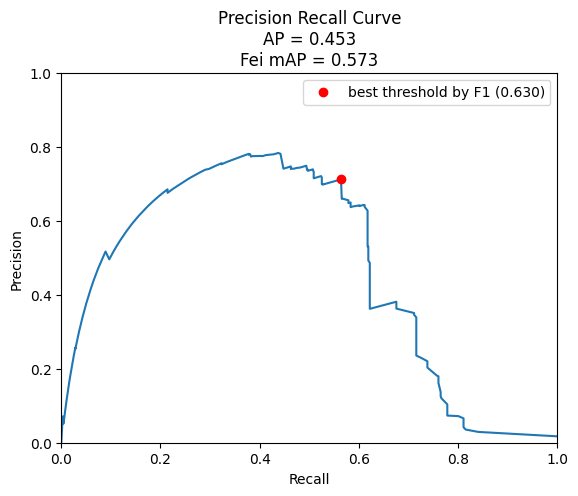

In [15]:
test(clip_model, proj, "simclr_only_test1", testLoader, y_test)